In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
import sys
sys.path.append('../')

from utils.analyse_results import *

# Linkage

In [3]:
dirname = '../tests/linkage/'
linkage_gain = load_results_linkage(dirname)

In [4]:
print(linkage_gain)

     TargetID        TargetModel    FeatureSet Run  TPSyn  FPSyn  \
0     ID14086  BayesianNetBins10  Correlations   0    0.6    0.2   
1     ID14086  BayesianNetBins10  Correlations   1    0.8    0.2   
2     ID14086  BayesianNetBins10  Correlations  10    0.6    0.6   
3     ID14086  BayesianNetBins10  Correlations  11    0.6    0.2   
4     ID14086  BayesianNetBins10  Correlations  12    1.0    0.2   
...       ...                ...           ...  ..    ...    ...   
2995  ID31432     SanitiserNHSk5         Naive   5    1.0    1.0   
2996  ID31432     SanitiserNHSk5         Naive   6    1.0    1.0   
2997  ID31432     SanitiserNHSk5         Naive   7    1.0    1.0   
2998  ID31432     SanitiserNHSk5         Naive   8    1.0    1.0   
2999  ID31432     SanitiserNHSk5         Naive   9    0.0    0.0   

      AdvantageSyn  AdvantageRaw  PrivacyGain  
0              0.4             1          0.6  
1              0.6             1          0.4  
2              0.0             1       

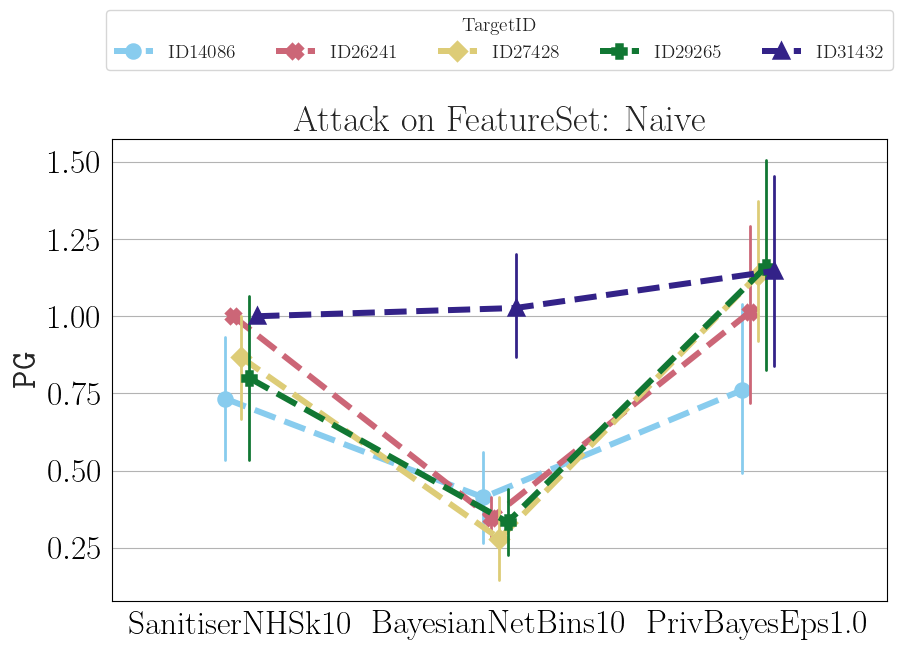

In [6]:
models = ['SanitiserNHSk10', 'BayesianNetBins10', 'PrivBayesEps1.0']
fig = plt_per_target_pg(linkage_gain, models, resFilter=('FeatureSet', 'Naive'))

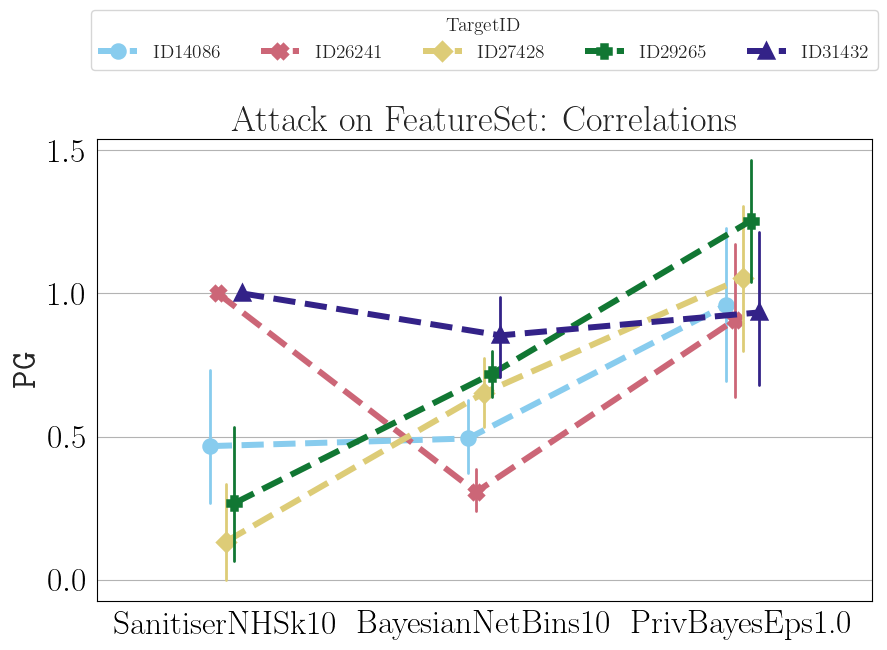

In [7]:
models = ['SanitiserNHSk10', 'BayesianNetBins10', 'PrivBayesEps1.0']
fig = plt_per_target_pg(linkage_gain, models, resFilter=('FeatureSet', 'Correlations'))

# Inference

In [14]:
dirname = '../tests/inference/'
dpath = '../data/texas'
inference_gain = load_results_inference(dirname, dpath)

inference_gain['TargetModel'] = inference_gain['TargetModel'].apply(
    lambda x: x[0] if isinstance(x, tuple) else x
)

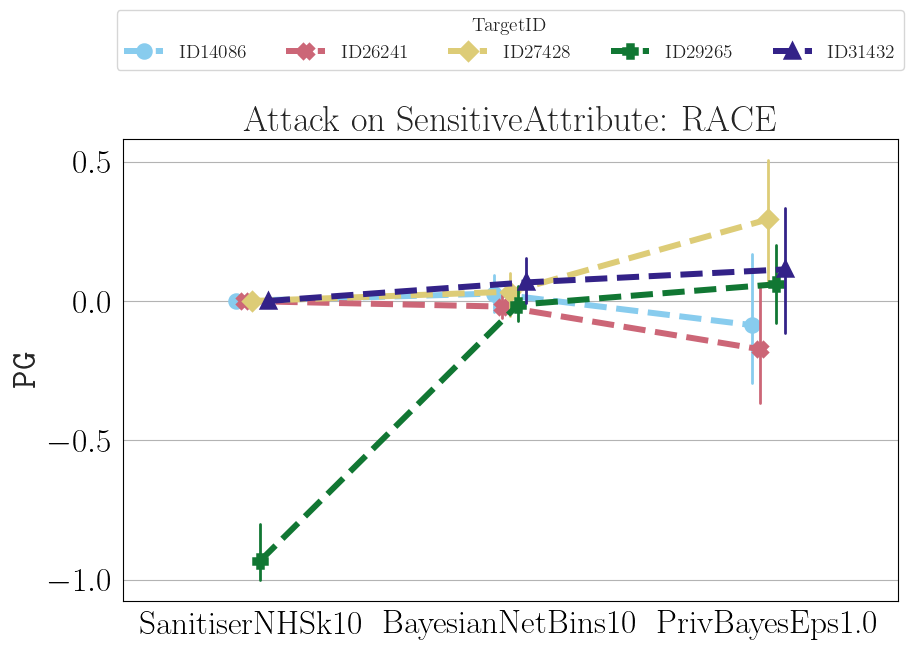

In [15]:
models = ['SanitiserNHSk10', 'BayesianNetBins10', 'PrivBayesEps1.0']
fig = plt_per_target_pg(inference_gain, models, resFilter=('SensitiveAttribute', 'RACE'))

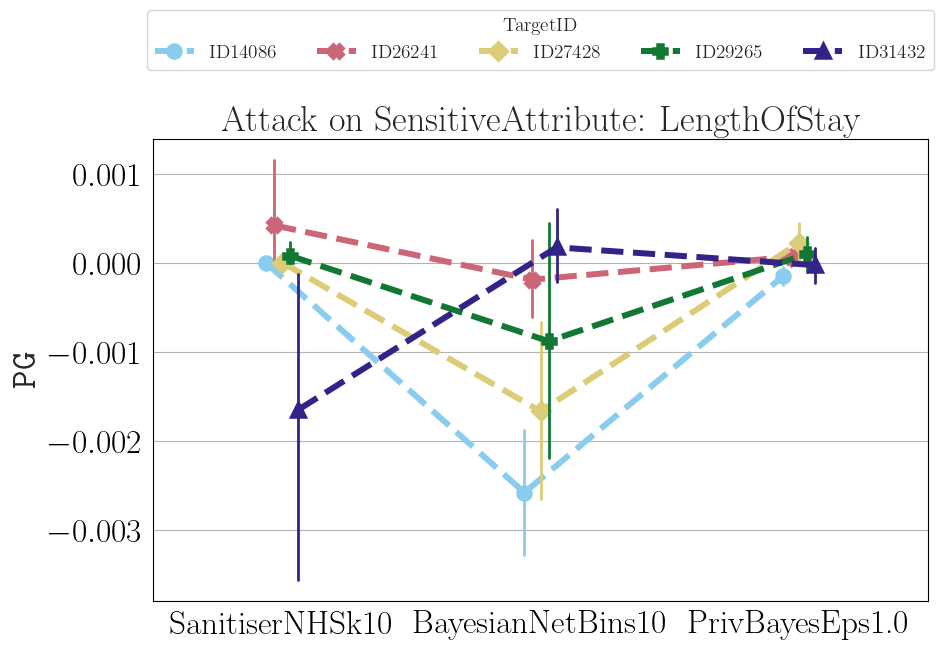

In [16]:
fig = plt_per_target_pg(inference_gain, models, resFilter=('SensitiveAttribute', 'LengthOfStay'))

# Aggregate Utility

In [20]:
dirname = '../tests/utility/'
utility_record, utility_agg = load_results_utility(dirname)
utility_agg = utility_agg.reset_index(drop=True)

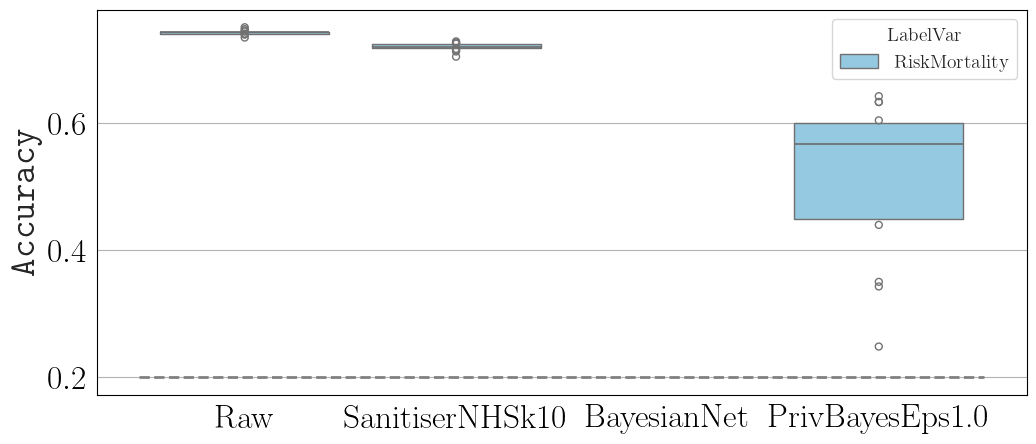

In [23]:
labelVar = 'RiskMortality'
models = ['Raw','SanitiserNHSk10', 'BayesianNet', 'PrivBayesEps1.0']
fig = plt_avg_accuracy(utility_agg, models)